In [15]:
## first, import the necessary modules

import os 
import sys
import glob
import numpy as np
import pylab as plt
import pandas as pd
import random
import subprocess
import sorcha

In [5]:
## define our filepaths and filename stems

## filepath for sorcha input and output files
sfpath = "/home/ellie/research/lsst/sorcha_output/2000_ext/" #obj/"

## read in filename list

df = pd.read_csv('orb_files2.csv')
ofnames = df['of_names']

In [6]:
print(of_names)

0            2000_ext_cart
1     2000_ext_ng_a1_-12.0
2     2000_ext_ng_a2_-12.0
3     2000_ext_ng_a3_-12.0
4     2000_ext_ng_a1_-11.0
5     2000_ext_ng_a2_-11.0
6     2000_ext_ng_a3_-11.0
7     2000_ext_ng_a1_-10.0
8     2000_ext_ng_a2_-10.0
9     2000_ext_ng_a3_-10.0
10     2000_ext_ng_a1_-9.0
11     2000_ext_ng_a2_-9.0
12     2000_ext_ng_a3_-9.0
13     2000_ext_ng_a1_-8.0
14     2000_ext_ng_a2_-8.0
15     2000_ext_ng_a3_-8.0
16     2000_ext_ng_a1_-7.0
17     2000_ext_ng_a2_-7.0
18     2000_ext_ng_a3_-7.0
19     2000_ext_ng_a1_-6.0
20     2000_ext_ng_a2_-6.0
21     2000_ext_ng_a3_-6.0
22     2000_ext_ng_a1_-5.0
23     2000_ext_ng_a2_-5.0
24     2000_ext_ng_a3_-5.0
25     2000_ext_ng_a1_-4.0
26     2000_ext_ng_a2_-4.0
27     2000_ext_ng_a3_-4.0
28     2000_ext_ng_a1_-3.0
29     2000_ext_ng_a2_-3.0
30     2000_ext_ng_a3_-3.0
31     2000_ext_ng_a1_-2.0
32     2000_ext_ng_a2_-2.0
33     2000_ext_ng_a3_-2.0
34     2000_ext_ng_a1_-1.0
35     2000_ext_ng_a2_-1.0
36     2000_ext_ng_a3_-1.0
3

In [36]:
## run link_purify -- first, create the lflist file

rms_vals = [1, 10, 100, 1000, 10000]

for rms in rms_vals:

    for m in range(len(ofnames)):
        with open('{0}{1}_lflist'.format(sfpath, ofnames[m]), 'w') as f:
            f.write("{0}sum_{1}.csv {0}clust2det_{1}.csv".format(sfpath, ofnames[m]))
            f.close()

            ## now, actually run link_purify
            subprocess.run(['link_purify','-imgs','{0}outim_{1}.txt'.format(sfpath, ofnames[m]),\
                            '-pairdets','{0}pairdets_{1}.csv'.format(sfpath, ofnames[m]), \
                            '-lflist','{0}{1}_lflist'.format(sfpath, ofnames[m]),\
                            '-max_astrom_rms', f'{rms}',\
                            '-outsum','{0}LPLsum_{1}_rms{2}.csv'.format(sfpath, ofnames[m], rms),\
                            '-clust2det','{0}LPLclust2det_{1}_rms{2}.csv'.format(sfpath, ofnames[m], rms)])

Checking out argv[1] = -imgs.
Checking out argv[3] = -pairdets.
Checking out argv[5] = -lflist.
Checking out argv[7] = -max_astrom_rms.
Checking out argv[9] = -outsum.
Checking out argv[11] = -clust2det.
input paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a1_-4.0.csv
input cluster list file /home/ellie/research/lsst/sorcha_output/2000_ext/2000_ext_ng_a1_-4.0_lflist
Maximum RMS in km: 100000
Maximum astrometric RMS: 1
Maximum fraction of points to be rejected: 0.5
Minimum number of observing nights: 3
Minimum number of unique detections: 6
output cluster file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLclust2det_2000_ext_ng_a1_-4.0_rms1.csv
output rms file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLsum_2000_ext_ng_a1_-4.0_rms1.csv
Reference MJD will be set to MJD-at-the-epoch from a previous orbit fit, if available.
Defaulting to simplex type = 1
Maximum fraction of points that can be rejected = 0.5, which is the default.
Ma

In [ ]:
## now, plot the results

In [37]:
fnames = []
fnames = fnames+glob.glob('/home/ellie/research/lsst/sorcha_output/2000_ext/2000_ext*30days.csv')

In [38]:
a1_counts = []
a1_nongrav = []

a2_counts = []
a2_nongrav = []

a3_counts = []
a3_nongrav = []

ofnames = []

for f in fnames: 
    df = pd.read_csv(f)

    if 'a1' in f:
        a1_counts.append(df['ObjID'].nunique())
        a1_nongrav.append(float(f.split('_')[-2]))#[:-4]))
        #print(df['fieldMJD_TAI'][0])
        ofname = f.split('/')[-1]
        ofname = ofname.split('.')[:-2]
        ofname = ofname[0]+'.0'
        print(ofname)
        ofnames.append(ofname)
    elif 'a2' in f:
        a2_counts.append(df['ObjID'].nunique())
        a2_nongrav.append(float(f.split('_')[-2]))#[:-4]))
        #print(df['fieldMJD_TAI'][0])
        ofname = f.split('/')[-1]
        ofname = ofname.split('.')[:-2]
        ofname = ofname[0]+'.0'
        print(ofname)
        ofnames.append(ofname)
    elif 'a3' in f:
        a3_counts.append(df['ObjID'].nunique())
        a3_nongrav.append(float(f.split('_')[-2]))#[:-4]))
        #print(df['fieldMJD_TAI'][0])
        ofname = f.split('/')[-1]
        ofname = ofname.split('.')[:-2]
        ofname = ofname[0]+'.0'
        print(ofname)
        ofnames.append(ofname)
    else:
        #print('saving gravity-only')
        grav_counts = df['ObjID'].nunique()
        ofname = f.split('/')[-1]
        ofname = ofname.split('.')[-2]
        ofname = ofname[:-7]
        print(ofname)
        ofnames.append(ofname)
        #print(df['fieldMJD_TAI'][0])

2000_ext_ng_a1_-4.0
2000_ext_ng_a3_-4.0
2000_ext_ng_a3_-6.0
2000_ext_ng_a3_-5.0
2000_ext_ng_a3_-12.0
2000_ext_ng_a1_-9.0
2000_ext_ng_a2_-5.0
2000_ext_ng_a3_0.0
2000_ext_ng_a1_-11.0
2000_ext_ng_a3_1.0
2000_ext_ng_a2_-8.0
2000_ext_ng_a3_-11.0
2000_ext_ng_a2_-10.0
2000_ext_ng_a2_-1.0
2000_ext_ng_a2_0.0
2000_ext_ng_a3_-1.0
2000_ext_ng_a2_-12.0
2000_ext_ng_a3_-8.0
2000_ext_ng_a1_-6.0
2000_ext_ng_a1_-10.0
2000_ext_ng_a2_-7.0
2000_ext_ng_a1_-12.0
2000_ext_ng_a2_-11.0
2000_ext_ng_a3_-9.0
2000_ext_ng_a3_-3.0
2000_ext_ng_a1_-8.0
2000_ext_ng_a1_-5.0
2000_ext_ng_a3_-10.0
2000_ext_cart
2000_ext_ng_a2_-9.0
2000_ext_ng_a3_-7.0
2000_ext_ng_a2_-6.0
2000_ext_ng_a3_-2.0
2000_ext_ng_a1_-7.0


[[  0. 220.]
 [-12. 220.]
 [-11. 220.]
 [-10. 219.]
 [ -9. 221.]
 [ -8. 220.]
 [ -7. 219.]
 [ -6. 213.]
 [ -5. 205.]
 [ -4. 111.]]
[[-13. 220.]
 [-12. 222.]
 [-11. 219.]
 [-10. 221.]
 [ -9. 221.]
 [ -8. 219.]
 [ -7. 217.]
 [ -6. 214.]
 [ -5.  82.]
 [ -1. 205.]
 [  0.  34.]]
15
['-13.0', '-12.0', '-11.0', '-10.0', '-9.0', '-8.0', '-7.0', '-6.0', '-5.0', '-4.0', '-3.0', '-2.0', '-1.0', '0.0', '1.0']
[np.float64(220.0), np.float64(222.0), np.float64(219.0), np.float64(221.0), np.float64(221.0), np.float64(219.0), np.float64(217.0), np.float64(214.0), np.float64(82.0), 0.0, 0.0, 0.0, np.float64(205.0), np.float64(34.0), 0.0]
[[-12. 221.]
 [-11. 219.]
 [-10. 221.]
 [ -9. 220.]
 [ -8. 219.]
 [ -7. 216.]
 [ -6. 216.]
 [ -5. 209.]
 [ -4. 127.]
 [ -3. 130.]
 [ -2. 228.]
 [ -1. 237.]
 [  0. 158.]
 [  1.  85.]]
[220. 221. 219. 221. 220. 219. 216. 216. 209. 127. 130. 228. 237. 158.
  85.]


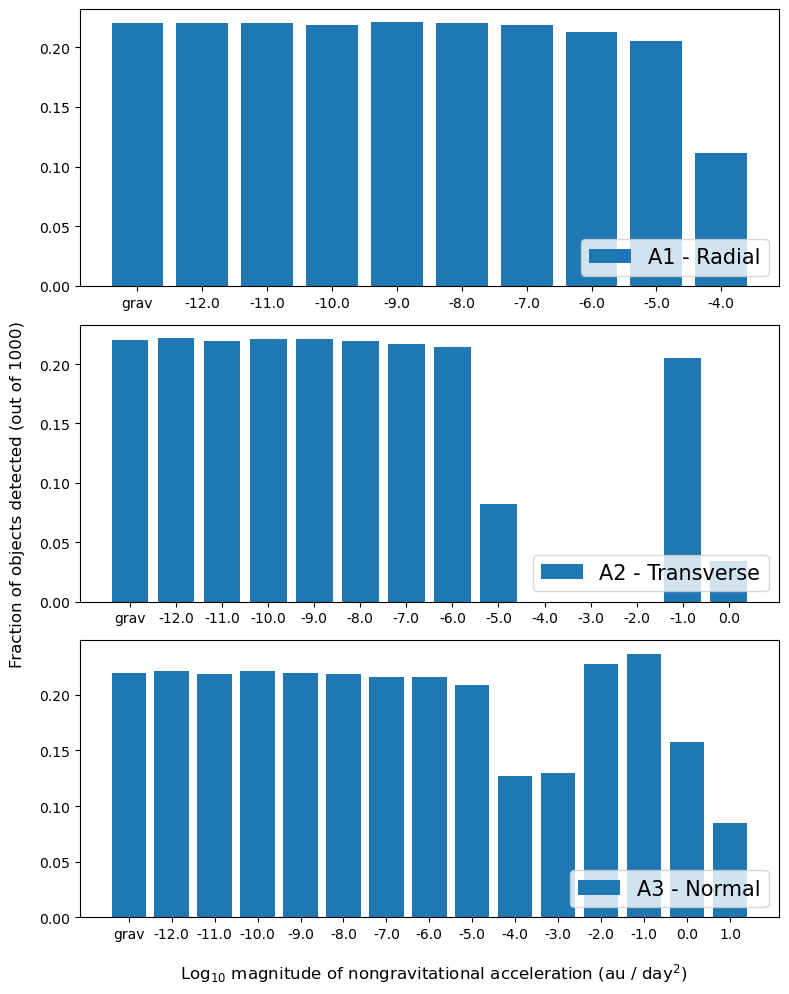

In [39]:
a1 = np.column_stack((np.array(a1_nongrav), np.array(a1_counts)))
sorted_idx = a1[:,0].argsort()
sorted_a1 = a1[sorted_idx]
sorted_a1 = np.concatenate((np.array([[0.0, grav_counts]]), sorted_a1))

#print(sorted_a1[:,1])
ax_labels = sorted_a1[:,0].tolist()
ax_labels[0] = 'grav'

ax_labels_str = []
for a in ax_labels:
    ax_labels_str.append(str(a))

print(sorted_a1)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
ax1.bar(ax_labels_str, sorted_a1[:,1]/1000, label='A1 - Radial')
#plt.ylim(1570,1600)
#plt.ylim(0.19, 0.20)
#ax1.set_ylabel('Fraction of objects detected (out of 2000)')
#ax1.set_xlabel('Log$_{10}$ magnitude of nongravitational acceleration (au / day$^2$)')
#ax1.set_title('Nongravitational acceleration component A1 - Radial')
ax1.legend(loc='lower right', fontsize=15)

a2 = np.column_stack((np.array(a2_nongrav), np.array(a2_counts)))
sorted_idx = a2[:,0].argsort()
sorted_a2 = a2[sorted_idx]
sorted_a2 = np.concatenate((np.array([[-13.0, grav_counts]]), sorted_a2))
a2_labels = sorted_a2[:,0].astype(str).tolist()

print(sorted_a2)
a2_counts_new = sorted_a2[:,1].tolist()
#a2_counts_new.insert(new_idx, a3_counts_new.pop(curr_idx))

ax_labels_str = ['-13.0', '-12.0','-11.0','-10.0','-9.0','-8.0','-7.0','-6.0','-5.0','-4.0','-3.0','-2.0','-1.0','0.0','1.0']
print(len(ax_labels_str))

a2_vals = []
i=0

for l in ax_labels_str:
    if l in ['-4.0','-3.0','-2.0','1.0']:
        a2_vals.append(0.0)
    else:
        a2_vals.append(sorted_a2[:,1][i])
        i += 1

print(ax_labels_str)
print(a2_vals)

ax_labels_str[0] = 'grav'

ax2.bar(ax_labels_str[:-1], np.array(a2_vals)[:-1]/1000, label='A2 - Transverse') #sorted_a2[:,1]/1000)
#plt.ylim(1570,1600)
#plt.ylim(0.785,0.80)
#plt.ylim(0.19, 0.20)
#ax2.set_ylabel('Fraction of objects detected (out of 1000)')
#ax2.set_xlabel('Log$_{10}$ magnitude of nongravitational acceleration (au / day$^2$)')
#ax2.set_title('Nongravitational acceleration component A2 - Transverse')
ax2.legend(loc='lower right', fontsize=15)

a3 = np.column_stack((np.array(a3_nongrav), np.array(a3_counts)))
sorted_idx = a3[:,0].argsort()
sorted_a3 = a3[sorted_idx]
print(sorted_a3)
sorted_a3 = np.concatenate((np.array([[-13.0, grav_counts]]), sorted_a3))

print(sorted_a3[:,1])
a3_labels = sorted_a3[:,0].astype(str).tolist()
a3_counts_new = sorted_a3[:,1].tolist()

curr_idx = 0
new_idx = 12

a3_labels.insert(new_idx, a3_labels.pop(curr_idx))
a3_counts_new.insert(new_idx, a3_counts_new.pop(curr_idx))

a3_labels.insert(0, a3_labels.pop(-3))
a3_counts_new.insert(0, a3_counts_new.pop(-3))

a3_labels[0] = 'grav'

ax3.bar(a3_labels, np.array(a3_counts_new)/1000, label='A3 - Normal')
#plt.ylim(1570,1600)
#plt.ylim(0.785,0.80)
#plt.ylim(0.19, 0.20)
#ax3.set_ylabel('Fraction of objects detected (out of 1000)')
#ax3.set_xlabel('Log$_{10}$ magnitude of nongravitational acceleration (au / day$^2$)')
#ax3.set_title('Nongravitational acceleration component A3 - Normal')
ax3.legend(loc='lower right', fontsize=15)

#mid = (fig.subplotpars.right + fig.subplotpars.left) / 2
fig.supylabel('Fraction of objects detected (out of 1000)')
fig.supxlabel('Log$_{10}$ magnitude of nongravitational acceleration (au / day$^2$)', x=0.55)

fig.set_figwidth(8)
fig.set_figheight(10)
plt.tight_layout()
plt.savefig('sorcha_hist_all_1000.png', dpi=300)
plt.show()

In [41]:
## how many linkages?
#sfpath = "/home/ellie/research/lsst/sorcha_output/2000_obj/"
sfpath = "/home/ellie/research/lsst/sorcha_output/2000_ext/"

links = []

for n in range(len(ofnames)):
    links_n = []
    for r in rms_vals:
        if os.path.isfile('{0}LPLsum_{1}_rms{2}.csv'.format(sfpath, ofnames[n], r)):
            df_links = pd.read_csv('{0}LPLsum_{1}_rms{2}.csv'.format(sfpath, ofnames[n], r))
            num_links = len(df_links)

            print(ofnames[n]+' - '+str(num_links))
            #plt.scatter(df_links['orbit_a'], df_links['orbit_e'], marker='.')
            links_n.append(num_links)
        else:
            print('{0}LPLsum_{1}.csv does not exist'.format(sfpath, ofnames[n]))
    links.append(links_n)

print(links)

2000_ext_ng_a1_-4.0 - 38
2000_ext_ng_a1_-4.0 - 38
2000_ext_ng_a1_-4.0 - 38
2000_ext_ng_a1_-4.0 - 38
2000_ext_ng_a1_-4.0 - 38
2000_ext_ng_a3_-4.0 - 113
2000_ext_ng_a3_-4.0 - 116
2000_ext_ng_a3_-4.0 - 116
2000_ext_ng_a3_-4.0 - 116
2000_ext_ng_a3_-4.0 - 116
2000_ext_ng_a3_-6.0 - 161
2000_ext_ng_a3_-6.0 - 161
2000_ext_ng_a3_-6.0 - 161
2000_ext_ng_a3_-6.0 - 161
2000_ext_ng_a3_-6.0 - 161
2000_ext_ng_a3_-5.0 - 192
2000_ext_ng_a3_-5.0 - 192
2000_ext_ng_a3_-5.0 - 192
2000_ext_ng_a3_-5.0 - 192
2000_ext_ng_a3_-5.0 - 192
2000_ext_ng_a3_-12.0 - 144
2000_ext_ng_a3_-12.0 - 144
2000_ext_ng_a3_-12.0 - 144
2000_ext_ng_a3_-12.0 - 144
2000_ext_ng_a3_-12.0 - 144
2000_ext_ng_a1_-9.0 - 145
2000_ext_ng_a1_-9.0 - 145
2000_ext_ng_a1_-9.0 - 145
2000_ext_ng_a1_-9.0 - 145
2000_ext_ng_a1_-9.0 - 145
2000_ext_ng_a2_-5.0 - 37
2000_ext_ng_a2_-5.0 - 37
2000_ext_ng_a2_-5.0 - 37
2000_ext_ng_a2_-5.0 - 37
2000_ext_ng_a2_-5.0 - 37
2000_ext_ng_a3_0.0 - 0
2000_ext_ng_a3_0.0 - 0
2000_ext_ng_a3_0.0 - 0
2000_ext_ng_a3_0.0 - 0
200

In [35]:
a1_links = []
a1_ngas = []

a2_links = []
a2_ngas = []

a3_links = []
a3_ngas = []

for l in range(len(ofnames)): 

    if 'a1' in ofnames[l]:
        a1_links.append(links[l])
        #print(ofnames[l].split('_')[-1])
        a1_ngas.append(float(ofnames[l].split('_')[-1]))
        print('a1: '+ofnames[l])

    elif 'a2' in ofnames[l]:
        a2_links.append(links[l])
        #print(ofnames[l].split('_')[-1])
        a2_ngas.append(float(ofnames[l].split('_')[-1]))
        print('a2: '+ofnames[l])
        
    elif 'a3' in ofnames[l]:
        a3_links.append(links[l])
        #print(ofnames[l].split('_')[-1])
        a3_ngas.append(float(ofnames[l].split('_')[-1]))
        print('a3: '+ofnames[l])

    else:
        print('saving gravity-only')
        grav_links = links[l]

print(a1_links)
print(a2_links)
print(a3_links)

a1: 2000_ext_ng_a1_-4.0
a3: 2000_ext_ng_a3_-4.0
a3: 2000_ext_ng_a3_-6.0
a3: 2000_ext_ng_a3_-5.0
a3: 2000_ext_ng_a3_-12.0
a1: 2000_ext_ng_a1_-9.0
a2: 2000_ext_ng_a2_-5.0
a3: 2000_ext_ng_a3_0.0
a1: 2000_ext_ng_a1_-11.0
a3: 2000_ext_ng_a3_1.0
a2: 2000_ext_ng_a2_-8.0
a3: 2000_ext_ng_a3_-11.0
a2: 2000_ext_ng_a2_-10.0
a2: 2000_ext_ng_a2_-1.0
a2: 2000_ext_ng_a2_0.0
a3: 2000_ext_ng_a3_-1.0
a2: 2000_ext_ng_a2_-12.0
a3: 2000_ext_ng_a3_-8.0
a1: 2000_ext_ng_a1_-6.0
a1: 2000_ext_ng_a1_-10.0
a2: 2000_ext_ng_a2_-7.0
a1: 2000_ext_ng_a1_-12.0
a2: 2000_ext_ng_a2_-11.0
a3: 2000_ext_ng_a3_-9.0
a3: 2000_ext_ng_a3_-3.0
a1: 2000_ext_ng_a1_-8.0
a1: 2000_ext_ng_a1_-5.0
a3: 2000_ext_ng_a3_-10.0
saving gravity-only
a2: 2000_ext_ng_a2_-9.0
a3: 2000_ext_ng_a3_-7.0
a2: 2000_ext_ng_a2_-6.0
a3: 2000_ext_ng_a3_-2.0
a1: 2000_ext_ng_a1_-7.0
[[38, 38, 38, 38, 38, 38, 38], [145, 145, 145, 145, 145, 145, 145], [143, 143, 143, 143, 143, 143, 143], [144, 144, 144, 144, 144, 144, 144], [144, 144, 144, 144, 144, 144, 144], [14

In [29]:
## filter out corrupted linkages using parse_clust2det
## replace all code below -- ignore except what is useful

ngas = ['cart', -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0] 
sfpath = "/home/ellie/research/lsst/sorcha_output/2000_ext/" #
parse_fnames = []

for n in ngas:

    #if os.path.isfile(f'{sfpath}LPLsum_{1}.csv'.format(sfpath, ofnames[n]))

    if n == 'cart':
        pairdet = f"{sfpath}pairdets_2000_ext_{str(n)}.csv"
        insum = f"{sfpath}LPLsum_2000_ext_{str(n)}.csv"
        clust2det = f"{sfpath}LPLclust2det_2000_ext_{str(n)}.csv"
        outfile = f"{sfpath}parse_clust2det_{str(n)}.csv"

        subprocess.run(['parse_clust2det','-pairdet',pairdet,'-insum', insum, '-clust2det', clust2det, '-out', outfile])
        parse_fnames.append(outfile)
        continue
    
    ## for a1
    pairdet_a1 = f"{sfpath}pairdets_2000_ext_ng_a1_{str(n)}.csv"
    insum_a1 = f"{sfpath}LPLsum_2000_ext_ng_a1_{str(n)}.csv"
    clust2det_a1 = f"{sfpath}LPLclust2det_2000_ext_ng_a1_{str(n)}.csv"
    outfile_a1 = f"{sfpath}parse_clust2det_a1_{str(n)}.csv"

    subprocess.run(['parse_clust2det','-pairdet',pairdet_a1,'-insum', insum_a1, '-clust2det', clust2det_a1, '-out', outfile_a1])

    ## for a2
    pairdet_a2 = f"{sfpath}pairdets_2000_ext_ng_a2_{str(n)}.csv"
    insum_a2 = f"{sfpath}LPLsum_2000_ext_ng_a2_{str(n)}.csv"
    clust2det_a2 = f"{sfpath}LPLclust2det_2000_ext_ng_a2_{str(n)}.csv"
    outfile_a2 = f"{sfpath}parse_clust2det_a2_{str(n)}.csv"

    subprocess.run(['parse_clust2det','-pairdet',pairdet_a2,'-insum', insum_a2, '-clust2det', clust2det_a2, '-out', outfile_a2])

    ## for a3
    pairdet_a3 = f"{sfpath}pairdets_2000_ext_ng_a3_{str(n)}.csv"
    insum_a3 = f"{sfpath}LPLsum_2000_ext_ng_a3_{str(n)}.csv"
    clust2det_a3 = f"{sfpath}LPLclust2det_2000_ext_ng_a3_{str(n)}.csv"
    outfile_a3 = f"{sfpath}parse_clust2det_a3_{str(n)}.csv"

    subprocess.run(['parse_clust2det','-pairdet',pairdet_a3,'-insum', insum_a3, '-clust2det', clust2det_a3, '-out', outfile_a3])

    parse_fnames.append(outfile_a1)
    parse_fnames.append(outfile_a2)
    parse_fnames.append(outfile_a3)

Checking out argv[1] = -pairdet.
Checking out argv[3] = -insum.
Checking out argv[5] = -clust2det.
Checking out argv[7] = -out.
input paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_cart.csv
input cluster summary file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLsum_2000_ext_cart.csv
input cluster-to-detection file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLclust2det_2000_ext_cart.csv
output file /home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_cart.csv
Read 3068 data lines from paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_cart.csv
Read 143 data lines from cluster summary file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLsum_2000_ext_cart.csv
Read 2679 data lines from cluster-to-detection file /home/ellie/research/lsst/sorcha_output/2000_ext/LPLclust2det_2000_ext_cart.csv
Wrote cluster detection vector with 2679 entries
Writing 143 clusters to output file /home/el

can't open input file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a2_-4.0.csv
ERROR: could not successfully read paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a2_-4.0.csv
read_pairdet_file returned status = 1.
can't open input file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a1_-3.0.csv
ERROR: could not successfully read paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a1_-3.0.csv
read_pairdet_file returned status = 1.
can't open input file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a2_-3.0.csv
ERROR: could not successfully read paired detection file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a2_-3.0.csv
read_pairdet_file returned status = 1.
can't open input file /home/ellie/research/lsst/sorcha_output/2000_ext/pairdets_2000_ext_ng_a1_-2.0.csv
ERROR: could not successfully read paired detectio

In [31]:
## why is a1_filtered_links returning all zeros? Sounds like an X File

a1_filtered_links = []
a1_all_links = []
a1_ngas = []
a1_false_links = []
a1_false_link_rates = []

a2_filtered_links = []
a2_all_links = []
a2_ngas = []
a2_false_links = []
a2_false_link_rates = []

a3_filtered_links = []
a3_all_links = []
a3_ngas = []
a3_false_links = []
a3_false_link_rates = []

for f in parse_fnames:

    if not os.path.isfile(f):
        print(f+' does not exist')
        continue
    
    cols = ['MJD','RA','Dec','mag','trail_len','trail_PA','sigmag','sig_across','sig_along',\
            'image','idstring','band','obscode','known_obj','det_qual','clusternum']
    
    df = pd.read_csv(f, skiprows=3, on_bad_lines='skip', names=cols, comment='#') #'warn')
    #print(df.head())
    
    cluster_nums = df['clusternum'].unique().tolist()
    bad_clusters = []
    #print(urows)

    prev_ids = []

    ## loop through each cluster and check if 
    for cluster in cluster_nums:
        df_cluster = df[df['clusternum'] == cluster]
        df_cluster.reset_index(drop=True, inplace=True) 

        #print(df_cluster['idstring'].nunique())
        
        if df_cluster['idstring'].nunique() == 1:
            ## now check if this id string has appeared in a previous linkage
            if df_cluster['idstring'][0] in prev_ids:
                bad_clusters.append(cluster)
            else:
                prev_ids.append(df_cluster['idstring'][0])
            
        else:
            bad_clusters.append(cluster)

    good_clusters = [item for item in cluster_nums if item not in bad_clusters]

    if 'a1' in f:
        a1_filtered_links.append(len(good_clusters))
        a1_all_links.append(len(cluster_nums))
        a1_ngas.append(f.split('_')[-1][:-4])
        print('in a1')
        print(bad_clusters)
        
        a1_false_links.append(len(bad_clusters))
        if len(cluster_nums) != 0:
            a1_false_link_rates.append((len(bad_clusters))/len(cluster_nums))
        else:
            a1_false_link_rates.append('undefined')
        
        print(f)
        continue

    if 'a2' in f:
        a2_filtered_links.append(len(good_clusters))
        a2_all_links.append(len(cluster_nums))
        a2_ngas.append(f.split('_')[-1][:-4])
        print('in a2')
        print(bad_clusters)
        
        a2_false_links.append(len(bad_clusters))
        if len(cluster_nums) != 0:
            a2_false_link_rates.append((len(bad_clusters))/len(cluster_nums))
        else:
            a2_false_link_rates.append('undefined')
        
        print(f)
        continue

    if 'a3' in f:
        a3_filtered_links.append(len(good_clusters))
        a3_all_links.append(len(cluster_nums))
        a3_ngas.append(f.split('_')[-1][:-4])
        print('in a3')
        print(bad_clusters)
        
        a3_false_links.append(len(bad_clusters))
        if len(cluster_nums) != 0:
            a3_false_link_rates.append((len(bad_clusters))/len(cluster_nums))
        else:
            a3_false_link_rates.append('undefined')
        
        print(f)
        continue

    else:
        grav_filtered_links = len(good_clusters)
        grav_all_links = len(cluster_nums)
        print('in grav only')
        print(bad_clusters)
        print(f)

print(a1_ngas)
print(a1_false_link_rates)
print()

print(a2_ngas)
print(a2_false_link_rates)
print()

print(a3_ngas)
print(a3_false_link_rates)
print()

'''print(grav_filtered_links)

print(a1_filtered_links)
print(a1_all_links)
print(a1_ngas)
print()

print(a2_filtered_links)
print(a2_all_links)
print(a2_ngas)
print()

print(a3_filtered_links)
print(a3_all_links)
print(a3_ngas)
print()'''

in grav only
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_cart.csv
in a1
[134]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a1_-12.0.csv
in a2
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a2_-12.0.csv
in a3
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a3_-12.0.csv
in a1
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a1_-11.0.csv
in a2
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a2_-11.0.csv
in a3
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a3_-11.0.csv
in a1
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a1_-10.0.csv
in a2
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a2_-10.0.csv
in a3
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a3_-10.0.csv
in a1
[]
/home/ellie/research/lsst/sorcha_output/2000_ext/parse_clust2det_a1_-9.0.csv
in a2
[]
/home/ellie/research/lsst/sor

'print(grav_filtered_links)\n\nprint(a1_filtered_links)\nprint(a1_all_links)\nprint(a1_ngas)\nprint()\n\nprint(a2_filtered_links)\nprint(a2_all_links)\nprint(a2_ngas)\nprint()\n\nprint(a3_filtered_links)\nprint(a3_all_links)\nprint(a3_ngas)\nprint()'

0.9860139860139859
1.0
1.0115911485774498
1.0093978419770275
1.0
1.0256410256410255
1.0400866738894907
1.1407129455909943
0.5128205128205128
-12.0
-11.0
-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0


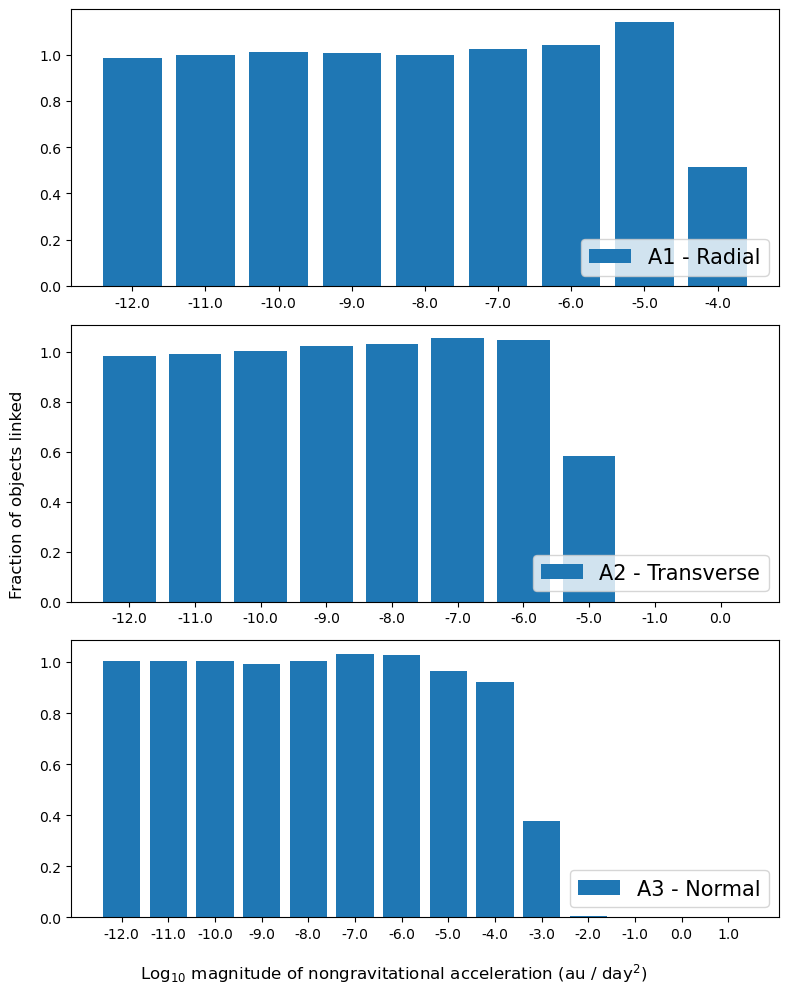

In [32]:
## now, plot the new link histograms: 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

x_vals = np.array(a1_ngas).astype(str).tolist()
#x_vals[0] = 'only grav'

a1_filtered_links_g = [grav_filtered_links]+a1_filtered_links

a1_link_fraction = []
for m in range(len(a1_filtered_links_g)):
    a1_link_fraction.append(a1_filtered_links_g[m]/sorted_a1[:,1][m])

a1_link_frac_wrt_grav = []
for l in range(len(a1_link_fraction)-1):
    a1_link_frac_wrt_grav.append(a1_link_fraction[l+1]/a1_link_fraction[0])

for a in a1_link_frac_wrt_grav:
    print(a.item())

for x in x_vals:
    print(x)
#print(x_vals[1:])

ax1.bar(x_vals, a1_link_frac_wrt_grav, label='A1 - Radial')
ax1.legend(loc='lower right', fontsize=15)

x_vals = np.array(a2_ngas).astype(str).tolist()
#x_vals[0] = 'only grav'

a2_filtered_links_g = [grav_filtered_links]+a2_filtered_links

a2_link_fraction = []
for m in range(len(a2_filtered_links_g)):
    a2_link_fraction.append(a2_filtered_links_g[m]/sorted_a2[:,1][m])

a2_link_frac_wrt_grav = []
for l in range(len(a2_link_fraction)-1):
    a2_link_frac_wrt_grav.append(a2_link_fraction[l+1]/a2_link_fraction[0])
    #print(a2_link_fraction[l+1]/a2_link_fraction[0])

'''x_vals = np.insert(x_vals, 8, '-4.0')
a2_link_frac_wrt_grav = np.insert(a2_link_frac_wrt_grav, 8, 0.0)

x_vals = np.insert(x_vals, 9, '-3.0')
a2_link_frac_wrt_grav = np.insert(a2_link_frac_wrt_grav, 9, 0.0)

x_vals = np.insert(x_vals, 10, '-2.0')
a2_link_frac_wrt_grav = np.insert(a2_link_frac_wrt_grav, 10, 0.0)'''

#print(a2_link_frac_wrt_grav)

ax2.bar(x_vals, a2_link_frac_wrt_grav, label='A2 - Transverse')
ax2.legend(loc='lower right', fontsize=15)

x_vals = np.array(a3_ngas).astype(str).tolist()
#x_vals[0] = 'only grav'

a3_filtered_links_g = [grav_filtered_links]+a3_filtered_links

a3_link_fraction = []
for m in range(len(a3_filtered_links_g)):
    #print(a3_filtered_links_g[m])
    #print(sorted_a3[:,1][m])
    a3_link_fraction.append(a3_filtered_links_g[m]/sorted_a3[:,1][m])

a3_link_frac_wrt_grav = []
for l in range(len(a3_link_fraction)-1):
    a3_link_frac_wrt_grav.append(a3_link_fraction[l+1]/a3_link_fraction[0])
    #print(a3_link_fraction[l+1]/a3_link_fraction[0])

#print(a3_link_frac_wrt_grav)

#f = plt.figure()
#f.set_figwidth(8)

ax3.bar(x_vals, a3_link_frac_wrt_grav, label='A3 - Normal')
ax3.legend(loc='lower right', fontsize=15)

fig.supylabel('Fraction of objects linked')
fig.supxlabel('Log$_{10}$ magnitude of nongravitational acceleration (au / day$^2$)')

fig.set_figwidth(8)
fig.set_figheight(10)
plt.tight_layout()

plt.savefig('linkage_hist_filtered_ai_1000.png', dpi=300)
plt.show()

In [ ]:
## need to determine why previous plot is truncating at 10^-6, fix that issue, 
## then plot the three components, with different-colored histograms for each 
## max-rms value